In [1]:
%pip install -qU pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df=pd.read_csv("CustomerBehavior.csv")

In [3]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='str')

In [6]:
df.shape

(350, 11)

In [7]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [8]:
# Data types
print("\nData Types:")
print(df.dtypes)

# Basic information
print("\nDataset Info:")
df.info()


Data Types:
Customer ID                   int64
Gender                          str
Age                           int64
City                            str
Membership Type                 str
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase      int64
Satisfaction Level              str
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased        

### Checking Missing Values

In [9]:
missing = df.isnull().sum()

print(missing)

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_df

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


,Missing Values,Percentage
Customer ID,0,0.000000
Gender,0,0.000000
Age,0,0.000000
City,0,0.000000
Membership Type,0,0.000000
Total Spend,0,0.000000
Items Purchased,0,0.000000
Average Rating,0,0.000000
Discount Applied,0,0.000000
Days Since Last Purchase,0,0.000000


### Filling Satisfaction Level with Mode the Most Repeated Value

In [15]:
mode_satisfaction = df["Satisfaction Level"].mode()[0]

df["Satisfaction Level"] = df["Satisfaction Level"].fillna(
    mode_satisfaction
)

print("Missing values after treatment:")
print(df["Satisfaction Level"].isnull().sum())

Missing values after treatment:
0


### Check Duplicate Customers

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

print(
    "Duplicate Customer IDs:",
    df["Customer ID"].duplicated().sum()
)

Duplicate Rows: 0
Duplicate Customer IDs: 0


### Checking Unique Values

In [14]:
categorical_columns = [
    "Gender",
    "City",
    "Membership Type",
    "Discount Applied",
    "Satisfaction Level"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Gender ---
Gender
Female    175
Male      175
Name: count, dtype: int64

--- City ---
City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

--- Membership Type ---
Membership Type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64

--- Discount Applied ---
Discount Applied
True     175
False    175
Name: count, dtype: int64

--- Satisfaction Level ---
Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt 
import seaborn as sns 

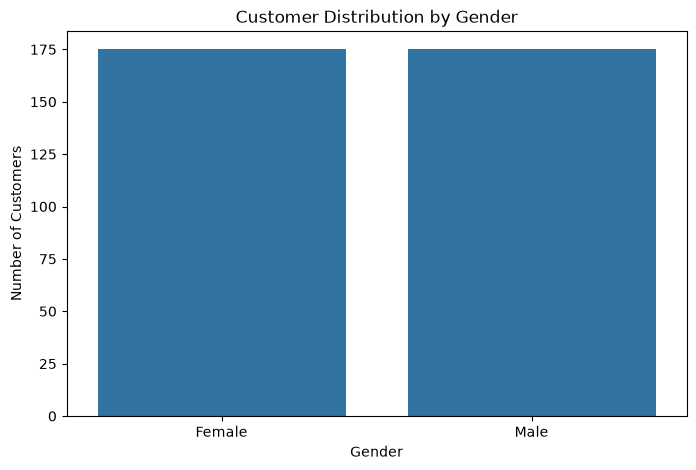

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

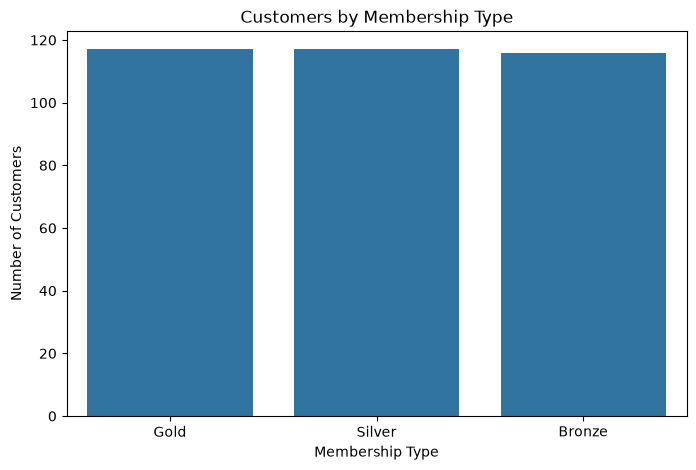

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Membership Type",
    order=df["Membership Type"].value_counts().index
)

plt.title("Customers by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Number of Customers")

plt.show()

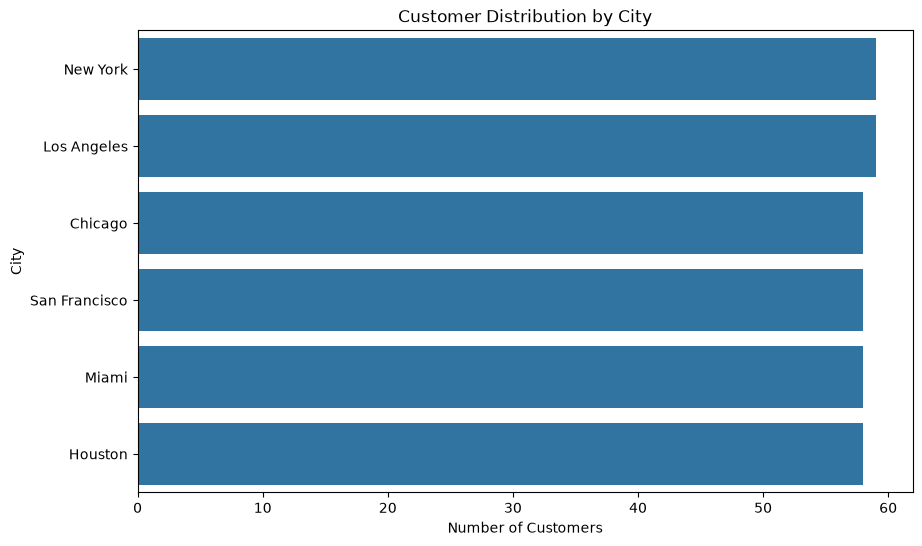

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="City",
    order=df["City"].value_counts().index
)

plt.title("Customer Distribution by City")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.show()

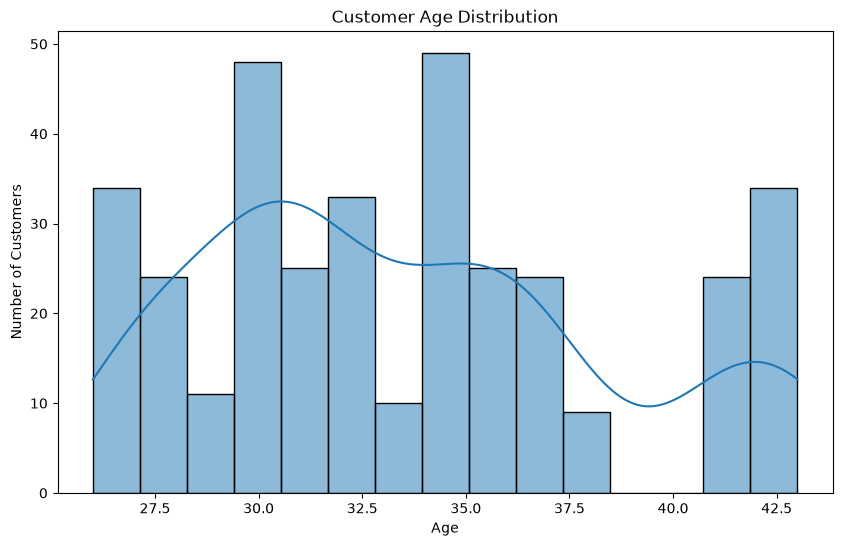

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

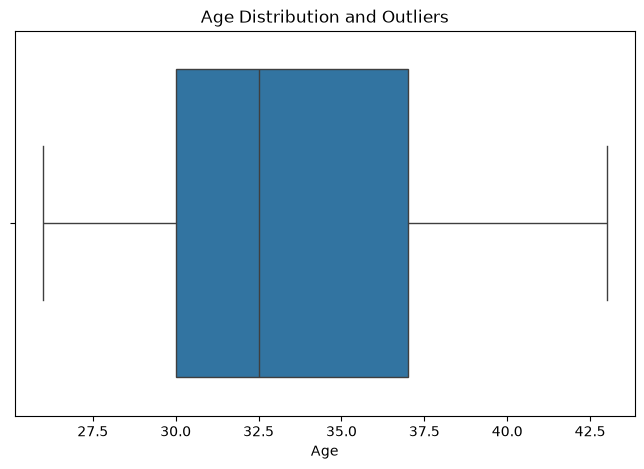

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Age"
)

plt.title("Age Distribution and Outliers")

plt.show()

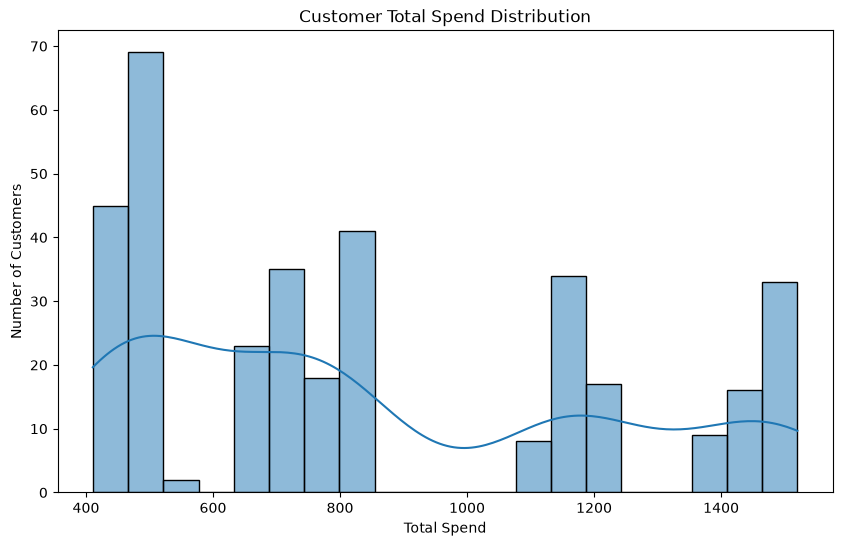

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Total Spend",
    bins=20,
    kde=True
)

plt.title("Customer Total Spend Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")

plt.show()

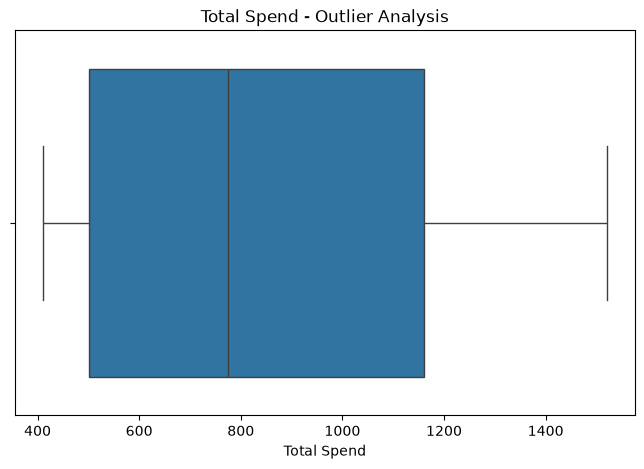

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Total Spend"
)

plt.title("Total Spend - Outlier Analysis")

plt.show()

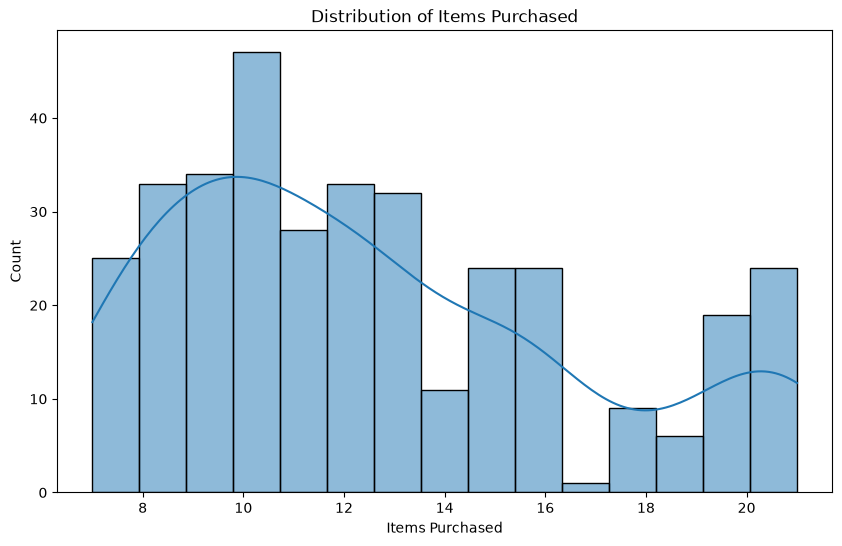

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Items Purchased",
    bins=15,
    kde=True
)

plt.title("Distribution of Items Purchased")

plt.show()

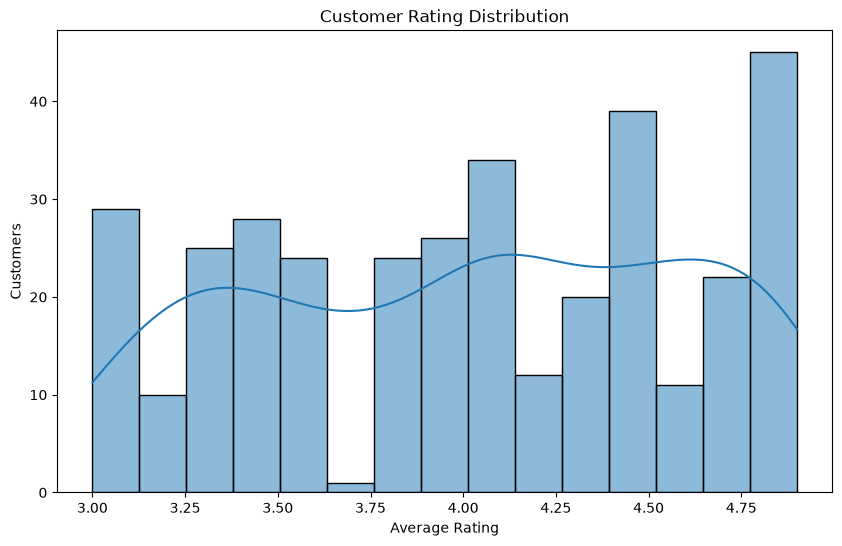

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Average Rating",
    bins=15,
    kde=True
)

plt.title("Customer Rating Distribution")
plt.xlabel("Average Rating")
plt.ylabel("Customers")

plt.show()

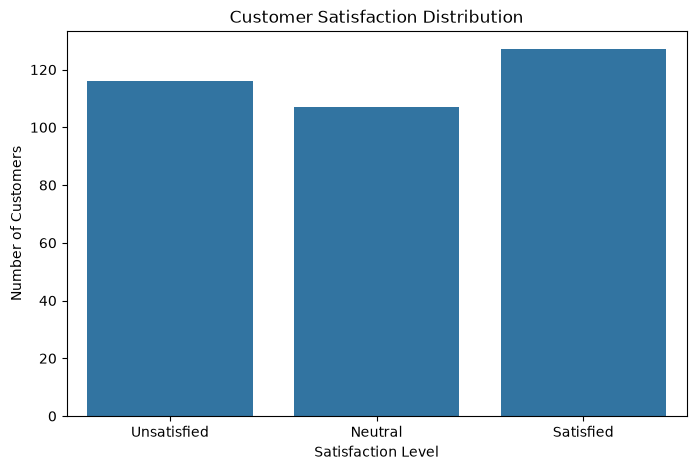

In [28]:
plt.figure(figsize=(8, 5))

order = ["Unsatisfied", "Neutral", "Satisfied"]

sns.countplot(
    data=df,
    x="Satisfaction Level",
    order=order
)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Customers")

plt.show()

In [29]:
satisfaction_percentage = (
    df["Satisfaction Level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(satisfaction_percentage)


Satisfaction Level
Satisfied      36.29
Unsatisfied    33.14
Neutral        30.57
Name: proportion, dtype: float64


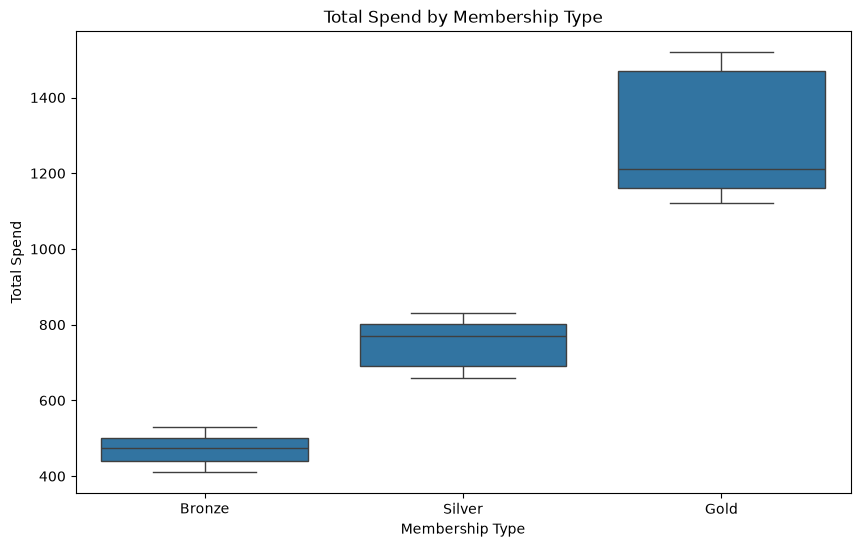

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Membership Type",
    y="Total Spend",
    order=["Bronze", "Silver", "Gold"]
)

plt.title("Total Spend by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Total Spend")

plt.show()

In [31]:
membership_spend = (
    df.groupby("Membership Type")["Total Spend"]
    .agg(["count", "mean", "median", "sum"])
    .sort_values("mean", ascending=False)
)

membership_spend

,count,mean,median,sum
Membership Type,,,,
Gold,117,1311.144444,1210.60,153403.9
Silver,117,748.432479,770.20,87566.6
Bronze,116,473.388793,475.25,54913.1


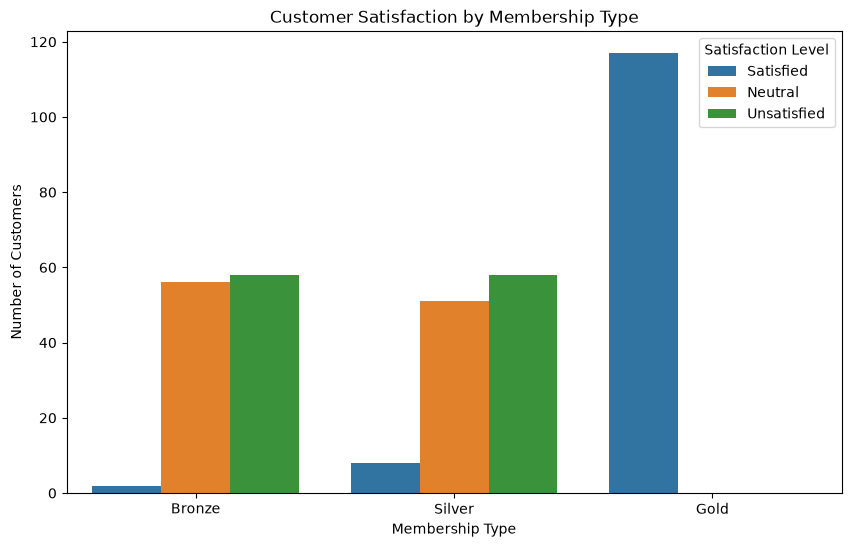

In [32]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Membership Type",
    hue="Satisfaction Level",
    order=["Bronze", "Silver", "Gold"]
)

plt.title("Customer Satisfaction by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Number of Customers")

plt.show()

In [33]:
membership_satisfaction = pd.crosstab(
    df["Membership Type"],
    df["Satisfaction Level"],
    normalize="index"
) * 100

membership_satisfaction

Satisfaction Level,Neutral,Satisfied,Unsatisfied
Membership Type,,,
Bronze,48.275862,1.724138,50.00000
Gold,0.000000,100.000000,0.00000
Silver,43.589744,6.837607,49.57265


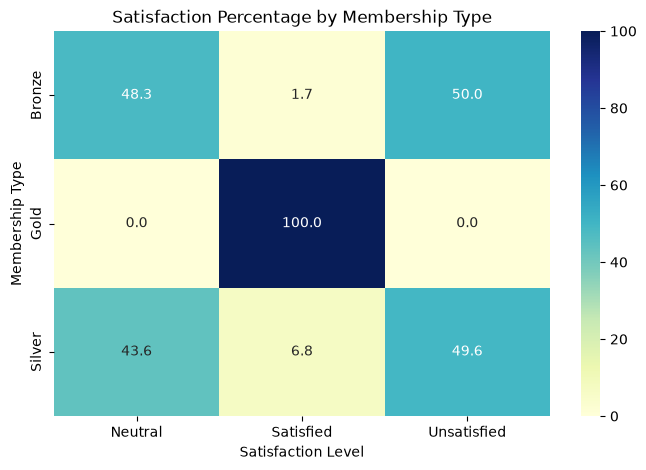

In [34]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    membership_satisfaction,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Satisfaction Percentage by Membership Type")
plt.xlabel("Satisfaction Level")
plt.ylabel("Membership Type")

plt.show()

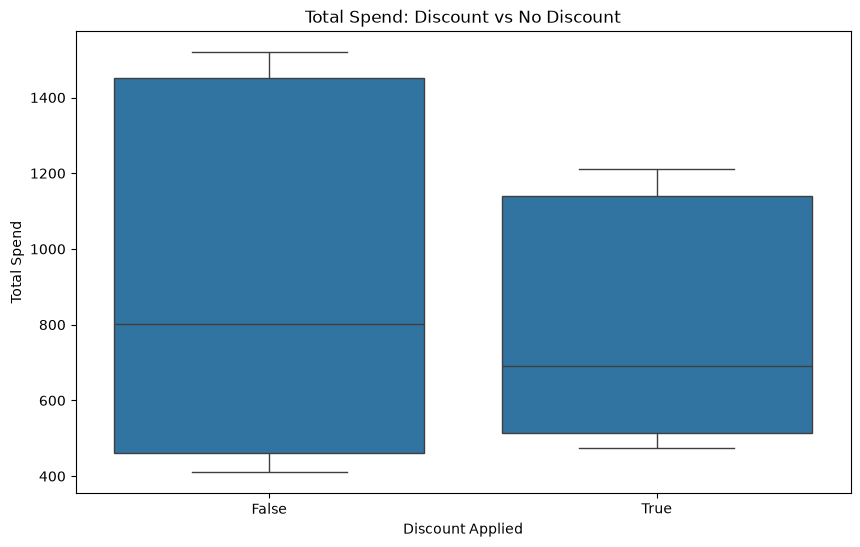

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Discount Applied",
    y="Total Spend"
)

plt.title("Total Spend: Discount vs No Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Total Spend")

plt.show()

In [36]:
df.groupby("Discount Applied")["Total Spend"].agg(
    ["count", "mean", "median", "sum"]
)

,count,mean,median,sum
Discount Applied,,,,
False,175,903.489714,800.9,158110.7
True,175,787.273714,690.6,137772.9


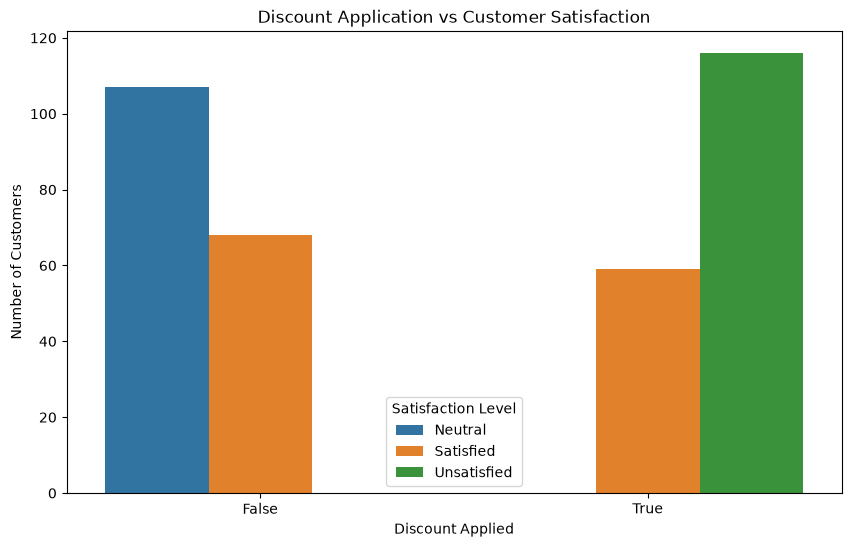

In [37]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Discount Applied",
    hue="Satisfaction Level"
)

plt.title("Discount Application vs Customer Satisfaction")
plt.xlabel("Discount Applied")
plt.ylabel("Number of Customers")

plt.show()

### There are Unsatisfied Customers Let Analyze them

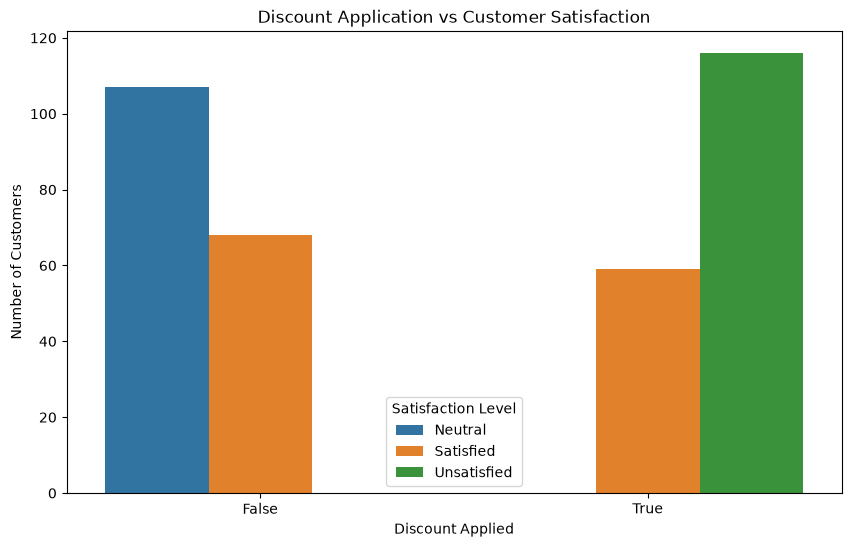

In [38]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Discount Applied",
    hue="Satisfaction Level"
)

plt.title("Discount Application vs Customer Satisfaction")
plt.xlabel("Discount Applied")
plt.ylabel("Number of Customers")

plt.show()

In [39]:
unsatisfied = df[
    df["Satisfaction Level"] == "Unsatisfied"
].copy()

print("Total Unsatisfied Customers:", len(unsatisfied))

print(
    "Percentage Unsatisfied:",
    round(
        len(unsatisfied) / len(df) * 100,
        2
    ),
    "%"
)

Total Unsatisfied Customers: 116
Percentage Unsatisfied: 33.14 %


In [40]:
unsatisfied[
    [
        "Customer ID",
        "Gender",
        "Age",
        "City",
        "Membership Type",
        "Total Spend",
        "Items Purchased",
        "Average Rating",
        "Discount Applied",
        "Days Since Last Purchase"
    ]
].sort_values(
    "Total Spend",
    ascending=False
)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase
201,302,Female,29,Miami,Silver,730.40,14,4.0,True,50
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55
243,344,Male,27,Miami,Silver,720.40,13,4.0,True,55
22,123,Male,27,Miami,Silver,710.40,13,4.1,True,54
112,213,Male,27,Miami,Silver,710.40,13,4.1,True,54
...,...,...,...,...,...,...,...,...,...,...
176,277,Female,41,Chicago,Bronze,480.25,9,3.6,True,38
295,396,Female,41,Chicago,Bronze,475.25,9,3.6,True,44
271,372,Female,41,Chicago,Bronze,475.25,9,3.6,True,42
319,420,Female,41,Chicago,Bronze,475.25,9,3.6,True,46


In [42]:
df["Unsatisfied"] = (
    df["Satisfaction Level"] == "Unsatisfied"
).astype(int)

df.groupby("Satisfaction Level")[
    [
        "Age",
        "Total Spend",
        "Items Purchased",
        "Average Rating",
        "Days Since Last Purchase"
    ]
].mean().round(2)

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Satisfaction Level,,,,,
Neutral,35.55,616.41,9.44,3.66,19.29
Satisfied,30.23,1266.86,17.16,4.62,17.76
Unsatisfied,35.48,595.14,10.53,3.69,42.98


In [43]:
discount_analysis = pd.crosstab(
    df["Discount Applied"],
    df["Satisfaction Level"],
    normalize="index"
) * 100

discount_analysis.round(2)

Satisfaction Level,Neutral,Satisfied,Unsatisfied
Discount Applied,,,
False,61.14,38.86,0.00
True,0.00,33.71,66.29


In [44]:
discount_analysis["Unsatisfied"]

Discount Applied
False     0.000000
True     66.285714
Name: Unsatisfied, dtype: float64

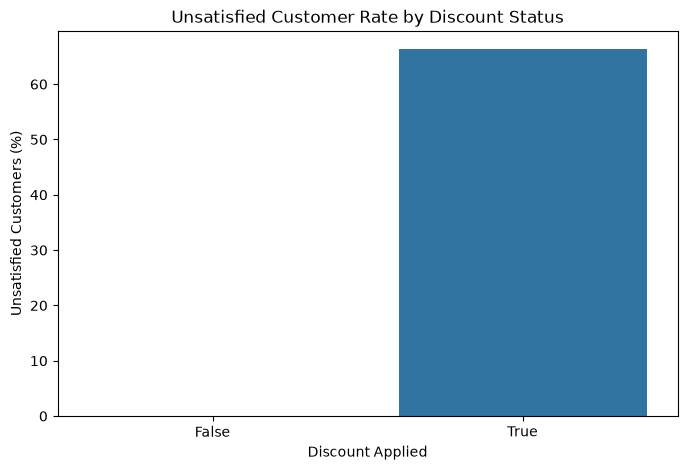

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=discount_analysis.index,
    y=discount_analysis["Unsatisfied"]
)

plt.title("Unsatisfied Customer Rate by Discount Status")
plt.xlabel("Discount Applied")
plt.ylabel("Unsatisfied Customers (%)")

plt.show()

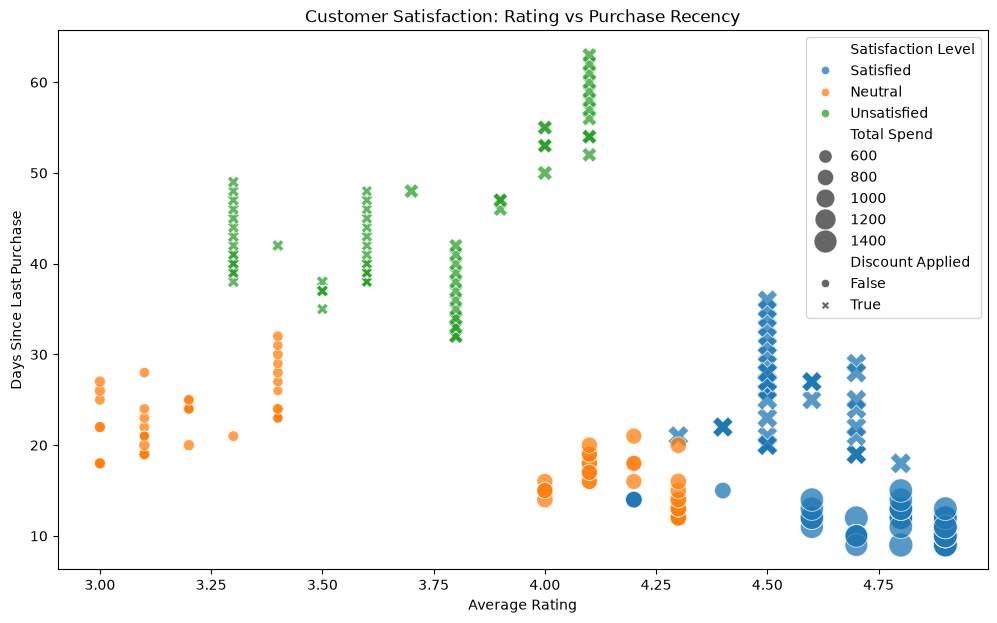

In [46]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Average Rating",
    y="Days Since Last Purchase",
    hue="Satisfaction Level",
    size="Total Spend",
    style="Discount Applied",
    sizes=(50, 300),
    alpha=0.75
)

plt.title(
    "Customer Satisfaction: Rating vs Purchase Recency"
)

plt.xlabel("Average Rating")
plt.ylabel("Days Since Last Purchase")

plt.show()

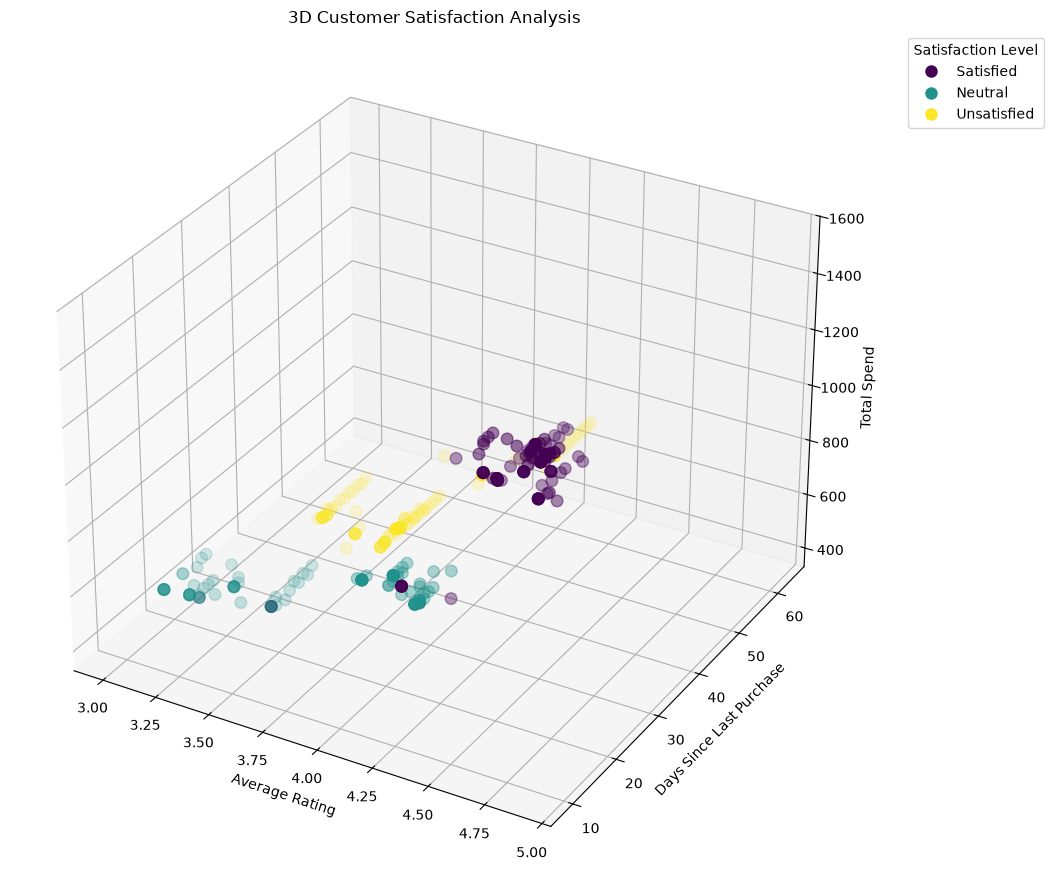

In [48]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(12, 9))

ax = fig.add_subplot(111, projection="3d")

# Map satisfaction levels to numeric values
satisfaction_map = {
    "Satisfied": 0,
    "Neutral": 1,
    "Unsatisfied": 2
}

colors = df["Satisfaction Level"].map(satisfaction_map)

# 3D Scatter Plot
scatter = ax.scatter(
    df["Average Rating"],
    df["Days Since Last Purchase"],
    df["Total Spend"],
    c=colors,
    cmap="viridis",
    s=70,
    alpha=0.75
)

# Axis labels
ax.set_xlabel("Average Rating")
ax.set_ylabel("Days Since Last Purchase")
ax.set_zlabel("Total Spend")

ax.set_title(
    "3D Customer Satisfaction Analysis"
)

# Create custom legend
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Satisfied",
        markerfacecolor=plt.cm.viridis(0 / 2),
        markersize=10
    ),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Neutral",
        markerfacecolor=plt.cm.viridis(1 / 2),
        markersize=10
    ),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Unsatisfied",
        markerfacecolor=plt.cm.viridis(2 / 2),
        markersize=10
    )
]

ax.legend(
    handles=legend_elements,
    title="Satisfaction Level",
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

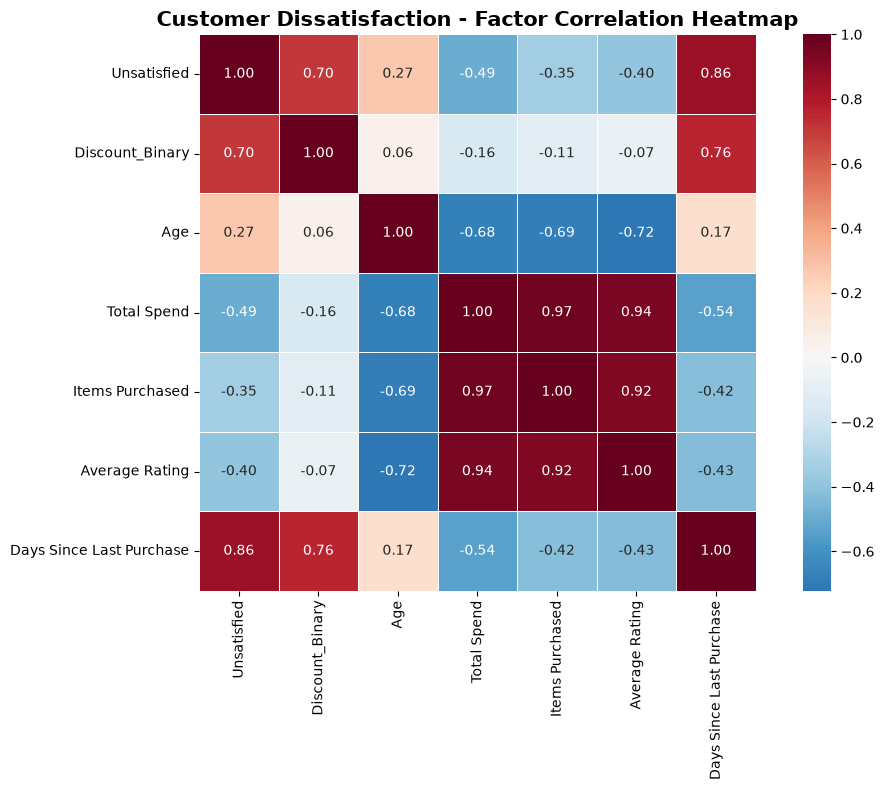

In [51]:
# Create binary variables
df["Unsatisfied"] = (
    df["Satisfaction Level"] == "Unsatisfied"
).astype(int)

df["Discount_Binary"] = (
    df["Discount Applied"] == True
).astype(int)

# Select important variables
heatmap_data = df[
    [
        "Unsatisfied",
        "Discount_Binary",
        "Age",
        "Total Spend",
        "Items Purchased",
        "Average Rating",
        "Days Since Last Purchase"
    ]
].corr()

# Plot
plt.figure(figsize=(11, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Customer Dissatisfaction - Factor Correlation Heatmap",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## MAKE EXECUTIVE SUMMARY